Mounted at /content/drive
Device: cuda

[PROCESS] 1. Menyiapkan Dataset A...
   -> Scanning Root: train | Kelas Utama: ['Benign', 'InSitu', 'Invasive', 'Normal']
   -> Scanning Root: val | Kelas Utama: ['Benign', 'InSitu', 'Invasive', 'Normal']
   -> Scanning Root: test | Kelas Utama: ['Benign', 'InSitu', 'Invasive', 'Normal']

[PROCESS] 2. Menyiapkan Breakhis (Deep Scan)...
   -> Scanning Root: Breakhis_200x | Kelas Utama: ['benign', 'malignant']
   Total gambar Breakhis ditemukan: 2013

[PROCESS] 3. Menggabungkan Dataset...
   Train Size : 1991 (A + Breakhis)
   Val Size   : 342 (A + Breakhis)
   Test Size  : 80 (Dataset A Only)

[INFO] Mapping Kelas: {'benign': 0, 'insitu': 1, 'invasive': 2, 'malignant': 3, 'normal': 4}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]


   >> RUN 1 dimulai (Seed 42)...


   >> Run 1 Selesai. Best Val F1: 0.9261
   -> Result Run 1 (Test F1): 0.5476


   >> RUN 2 dimulai (Seed 2024)...


   >> Run 2 Selesai. Best Val F1: 0.9292
   -> Result Run 2 (Test F1): 0.5444


   >> RUN 3 dimulai (Seed 999)...


   >> Run 3 Selesai. Best Val F1: 0.9189
   -> Result Run 3 (Test F1): 0.3316


 HASIL AKHIR GABUNGAN (Best Run: 1)
 Evaluasi pada Test Set Dataset A (Fair Comparison)


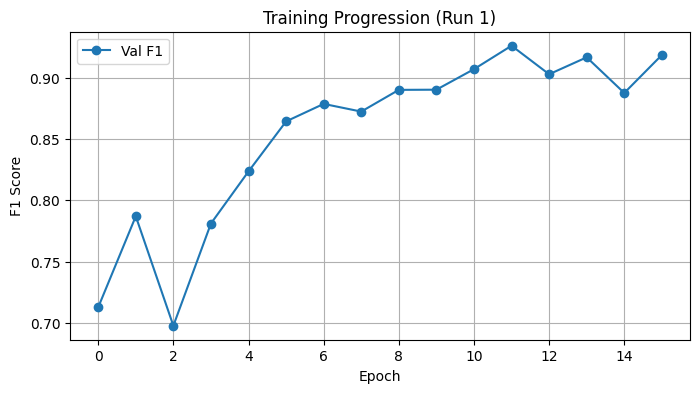

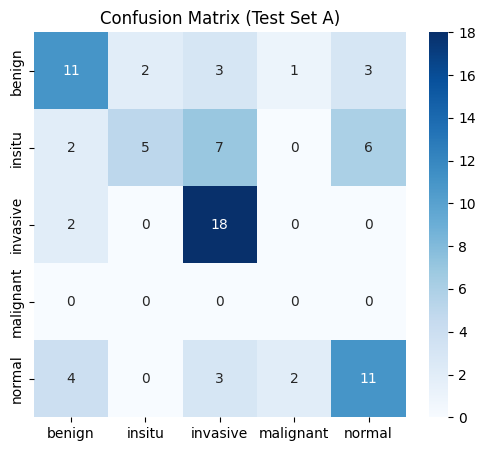


[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

      benign       0.58      0.55      0.56        20
      insitu       0.71      0.25      0.37        20
    invasive       0.58      0.90      0.71        20
   malignant       0.00      0.00      0.00         0
      normal       0.55      0.55      0.55        20

    accuracy                           0.56        80
   macro avg       0.48      0.45      0.44        80
weighted avg       0.61      0.56      0.55        80



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ==============================================================================
#  FINAL ROBUST PIPELINE: COMBINED DATASETS (A + BREAKHIS)
#  Fitur Utama:
#  1. Deep Scan (Recursive): Bisa membaca gambar dalam sub-folder (adenosis, dll).
#  2. Stability: Menggunakan num_workers=0 agar tidak crash di Colab.
#  3. Fair Comparison: Training Gabungan, tapi Testing HANYA pada Dataset A.
# ==============================================================================

import subprocess
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from google.colab import drive

# --- 1. INSTALL LIBRARY ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import timm
except ImportError:
    print("Installing timm...")
    install('timm')
    import timm

# --- 2. KONFIGURASI PATH (PASTIKAN INI BENAR) ---
# Sesuaikan dengan lokasi folder Anda di Google Drive
PATH_DATASET_A = '/content/drive/MyDrive/Breastcancerimager'
PATH_BREAKHIS  = '/content/drive/MyDrive/Breakhis_200x'

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 16
NUM_RUNS = 3
SEEDS = [42, 2024, 999]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print(f"Device: {DEVICE}")

# ==============================================================================
#  BAGIAN 1: DATA MANAGER (DEEP RECURSIVE SCAN)
# ==============================================================================

class CombinedDataManager:
    def __init__(self, path_a, path_breakhis):
        self.path_a = path_a
        self.path_b = path_breakhis

    def get_df_recursive(self, folder_path):
        """
        Fungsi ini mencari gambar hingga ke folder terdalam (Sub-folder).
        Sangat penting untuk struktur Breakhis (benign -> adenosis -> gambar).
        """
        if not os.path.exists(folder_path):
            print(f"[WARNING] Path tidak ditemukan: {folder_path}")
            return pd.DataFrame(columns=['filepath', 'label'])

        filepaths = []
        labels = []

        # Ambil nama folder kelas utama (misal: benign, malignant)
        try:
            classes = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])
        except:
            return pd.DataFrame(columns=['filepath', 'label'])

        print(f"   -> Scanning Root: {os.path.basename(folder_path)} | Kelas Utama: {classes}")

        for label in classes:
            class_path = os.path.join(folder_path, label)

            # os.walk akan menelusuri semua anak folder (Deep Search)
            count_per_class = 0
            for root, dirs, files in os.walk(class_path):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
                        fpath = os.path.join(root, file)
                        filepaths.append(fpath)
                        # Label diambil dari folder utama (misal 'benign'), bukan subfolder ('adenosis')
                        labels.append(label.lower())
                        count_per_class += 1

            # print(f"      - Kelas '{label}': Ditemukan {count_per_class} gambar.")

        df = pd.DataFrame({'filepath': filepaths, 'label': labels})
        return df

    def prepare_combined_data(self):
        print("\n[PROCESS] 1. Menyiapkan Dataset A...")
        df_train_a = self.get_df_recursive(os.path.join(self.path_a, 'train'))
        df_val_a   = self.get_df_recursive(os.path.join(self.path_a, 'val'))
        df_test_a  = self.get_df_recursive(os.path.join(self.path_a, 'test'))

        print("\n[PROCESS] 2. Menyiapkan Breakhis (Deep Scan)...")
        df_full_b = self.get_df_recursive(self.path_b)

        if not df_full_b.empty:
            print(f"   Total gambar Breakhis ditemukan: {len(df_full_b)}")
            # Split Breakhis: Masuk ke Train & Val, TAPI TIDAK KE TEST
            X = df_full_b['filepath']
            y = df_full_b['label']
            try:
                # Coba stratified split
                df_train_b, df_val_b = train_test_split(df_full_b, test_size=0.15, stratify=y, random_state=42)
            except ValueError:
                # Fallback jika error (misal jumlah data terlalu sedikit)
                df_train_b, df_val_b = train_test_split(df_full_b, test_size=0.15, random_state=42)
        else:
            print("   [ERROR] Breakhis masih kosong! Pastikan path benar.")
            df_train_b = pd.DataFrame()
            df_val_b = pd.DataFrame()

        # MERGE DATASETS
        print("\n[PROCESS] 3. Menggabungkan Dataset...")
        final_train = pd.concat([df_train_a, df_train_b], ignore_index=True)
        final_val = pd.concat([df_val_a, df_val_b], ignore_index=True)
        final_test = df_test_a # Penting: Test set murni dari Dataset A

        print(f"   Train Size : {len(final_train)} (A + Breakhis)")
        print(f"   Val Size   : {len(final_val)} (A + Breakhis)")
        print(f"   Test Size  : {len(final_test)} (Dataset A Only)")

        return final_train, final_val, final_test

class BreastCancerDataset(Dataset):
    def __init__(self, df, transform=None, class_map=None):
        self.df = df
        self.transform = transform
        self.class_map = class_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filepath']
        label_str = row['label']

        # Mapping label string ke integer
        if label_str in self.class_map:
            label = self.class_map[label_str]
        else:
            # Fallback (seharusnya tidak terjadi jika kelas konsisten)
            label = 0

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), label

# Augmentasi Gambar
transforms_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==============================================================================
#  BAGIAN 2: MODEL (ConvNeXt V2 + Attention)
# ==============================================================================

class SEBlock1D(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock1D, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.fc(x)
        return x * y

class ConvNeXtV2_Custom(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ConvNeXtV2_Custom, self).__init__()
        # Load Pretrained Backbone
        self.backbone = timm.create_model('convnextv2_tiny.fcmae', pretrained=pretrained, num_classes=0)
        num_features = self.backbone.num_features

        # Attention Module
        self.attention = SEBlock1D(num_features)

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Dropout(0.3),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        att_features = self.attention(features)
        out = self.classifier(att_features)
        return out

# ==============================================================================
#  BAGIAN 3: TRAINING LOOP
# ==============================================================================

def train_one_run(run_id, train_loader, val_loader, test_loader, num_classes, seed):
    # Set Random Seed untuk Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = ConvNeXtV2_Custom(num_classes=num_classes, pretrained=True).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    # Scheduler tanpa argumen 'verbose' (Fix error versi PyTorch baru)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

    best_f1 = 0.0
    history = {'loss': [], 'val_f1': []}
    model_save_path = f"best_combined_model_run_{run_id}.pth"

    print(f"\n   >> RUN {run_id} dimulai (Seed {seed})...")

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        # Training Loop
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation Loop
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(DEVICE)
                out = model(imgs)
                _, p = torch.max(out, 1)
                preds.extend(p.cpu().numpy())
                targets.extend(lbls.numpy())

        val_f1 = f1_score(targets, preds, average='weighted')
        history['loss'].append(train_loss/len(train_loader))
        history['val_f1'].append(val_f1)

        scheduler.step(val_f1)

        # Simpan Model Terbaik
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), model_save_path)

    print(f"   >> Run {run_id} Selesai. Best Val F1: {best_f1:.4f}")

    # --- FINAL TEST EVALUATION ---
    # Load bobot terbaik dan uji pada Dataset A
    model.load_state_dict(torch.load(model_save_path, weights_only=True))
    model.eval()

    t_preds, t_targets, t_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            probs = torch.softmax(out, dim=1)
            _, p = torch.max(out, 1)
            t_preds.extend(p.cpu().numpy())
            t_targets.extend(lbls.numpy())
            t_probs.extend(probs.cpu().numpy())

    final_test_f1 = f1_score(t_targets, t_preds, average='weighted')

    return {
        'run_id': run_id,
        'f1': final_test_f1,
        'history': history,
        'preds': t_preds,
        'targets': t_targets,
        'probs': np.array(t_probs)
    }

def analyze_final_results(results, class_map):
    best_res = max(results, key=lambda x: x['f1'])
    print(f"\n{'='*50}")
    print(f" HASIL AKHIR GABUNGAN (Best Run: {best_res['run_id']})")
    print(f" Evaluasi pada Test Set Dataset A (Fair Comparison)")
    print(f"{'='*50}")

    # 1. Plot Grafik Training
    plt.figure(figsize=(8, 4))
    plt.plot(best_res['history']['val_f1'], marker='o', label='Val F1')
    plt.title(f'Training Progression (Run {best_res["run_id"]})')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Confusion Matrix
    cm = confusion_matrix(best_res['targets'], best_res['preds'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_map.keys(), yticklabels=class_map.keys())
    plt.title('Confusion Matrix (Test Set A)')
    plt.show()

    # 3. Text Report
    print("\n[CLASSIFICATION REPORT]")
    print(classification_report(best_res['targets'], best_res['preds'], target_names=class_map.keys()))

# ==============================================================================
#  MAIN EXECUTION
# ==============================================================================

if __name__ == "__main__":
    # 1. Siapkan Data
    manager = CombinedDataManager(PATH_DATASET_A, PATH_BREAKHIS)
    train_df, val_df, test_df = manager.prepare_combined_data()

    if not train_df.empty and not test_df.empty:
        # 2. Setup Kelas & Dataloader
        classes = sorted(train_df['label'].unique())
        class_map = {k: v for v, k in enumerate(classes)}
        print(f"\n[INFO] Mapping Kelas: {class_map}")

        # PENTING: num_workers=0 untuk mencegah crash di Colab
        train_loader = DataLoader(BreastCancerDataset(train_df, transforms_train, class_map),
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(BreastCancerDataset(val_df, transforms_val, class_map),
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(BreastCancerDataset(test_df, transforms_val, class_map),
                                 batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        # 3. Jalankan 3 Runs
        all_results = []
        for i, seed in enumerate(SEEDS):
            res = train_one_run(i+1, train_loader, val_loader, test_loader, len(classes), seed)
            all_results.append(res)
            print(f"   -> Result Run {i+1} (Test F1): {res['f1']:.4f}\n")

        # 4. Analisis
        analyze_final_results(all_results, class_map)
    else:
        print("\n[CRITICAL ERROR] Data kosong. Mohon periksa path Google Drive Anda.")


 VISUALISASI PREDIKSI (SAMPEL ACAK DARI TEST SET DATASET A) 
[INFO] Menggunakan model: best_combined_model_run_1.pth


/tmp/ipython-input-893875252.py:96: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-893875252.py:96: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


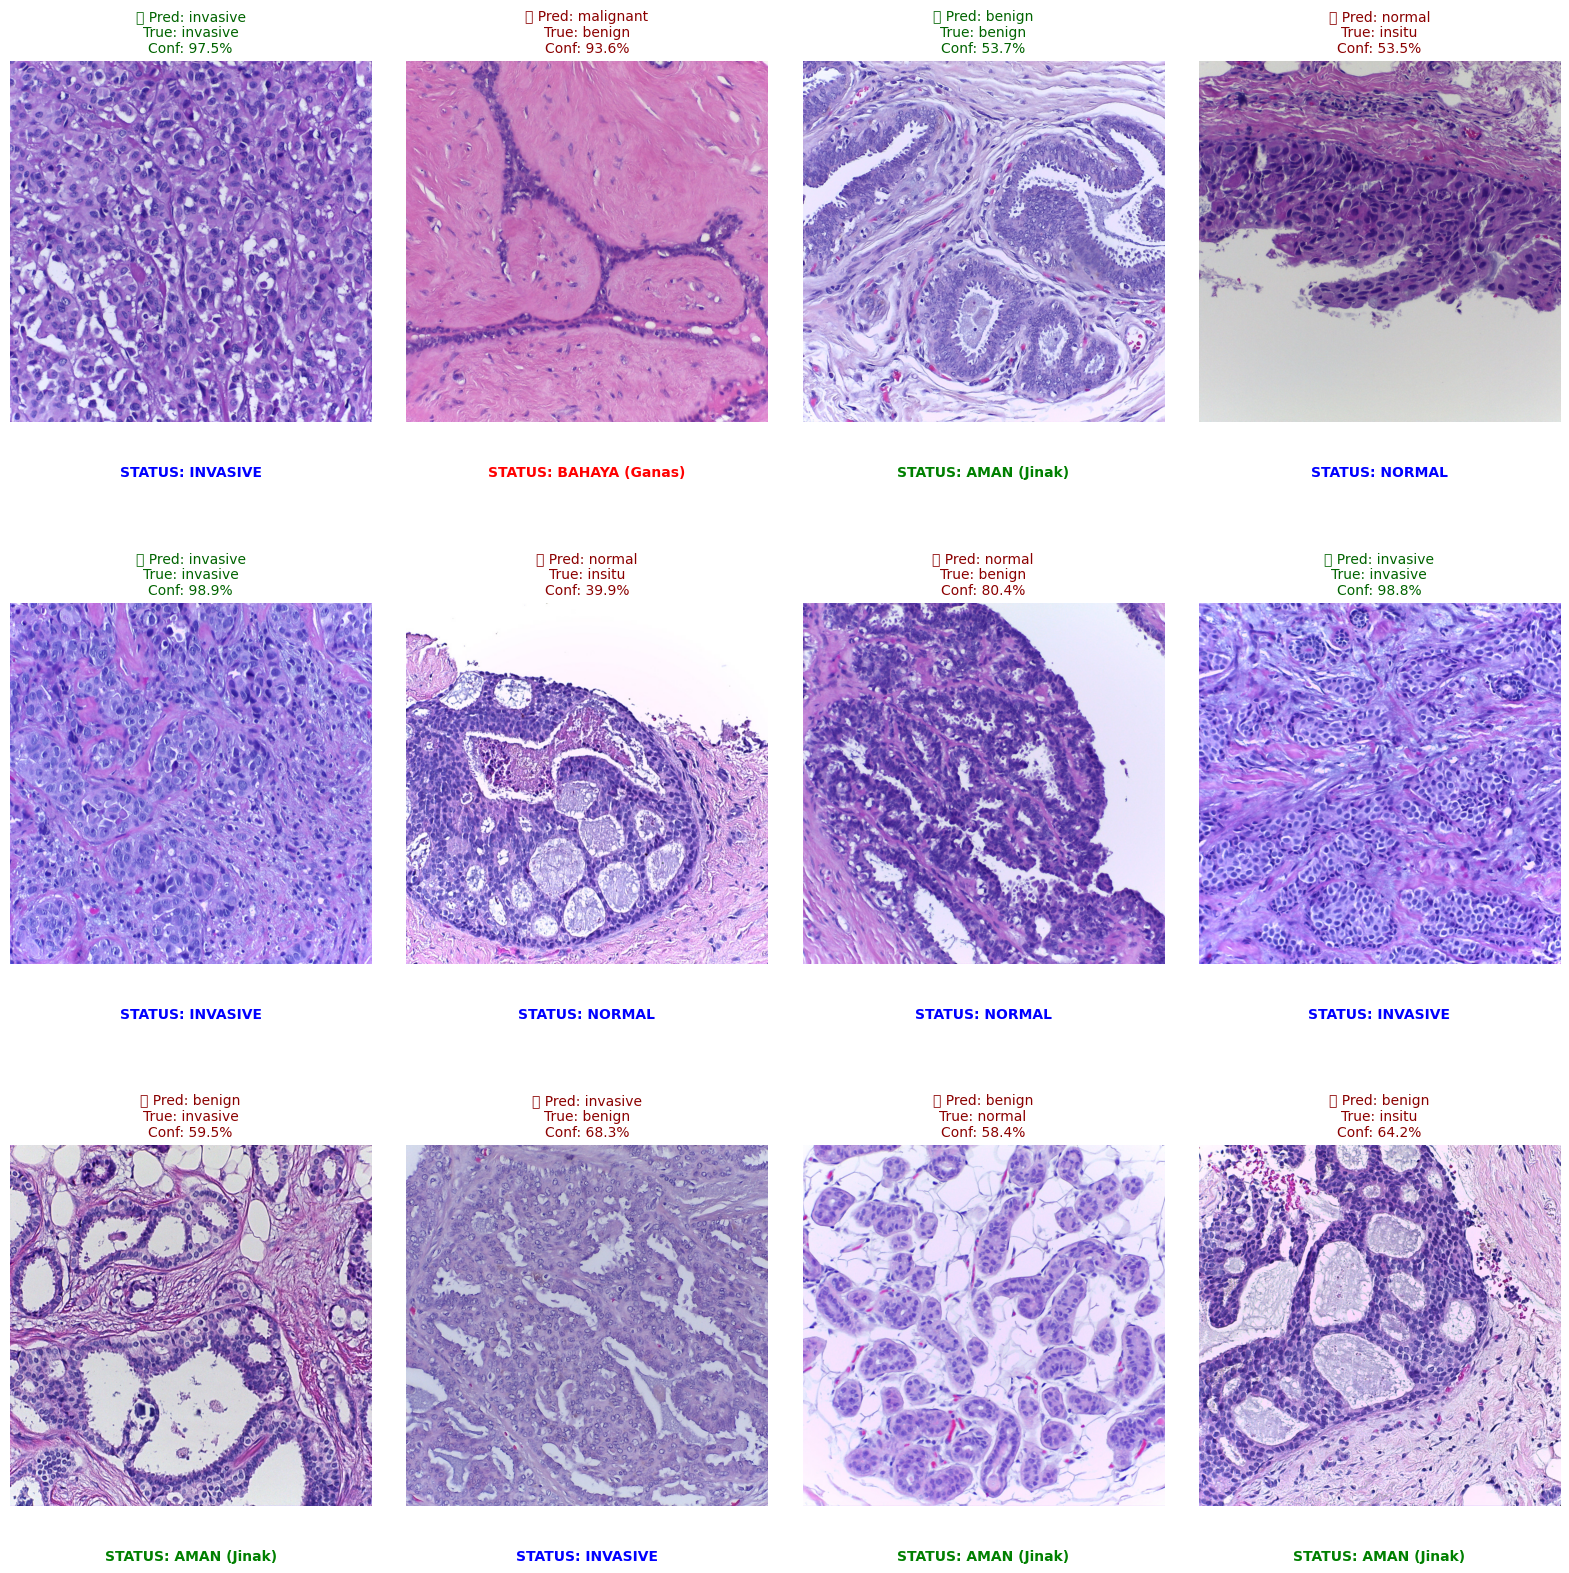

In [ ]:
# ==============================================================================
# BAGIAN 8: VISUALISASI PREDIKSI DARI DATA TEST (DATASET A ONLY)
# ==============================================================================
# Gunakan fungsi ini untuk melihat hasil prediksi pada sampel acak dari test set.

def visualize_test_predictions(model_path, test_dataframe, class_mapping, num_samples=12):
    print(f"\n{'='*60}")
    print(f" VISUALISASI PREDIKSI (SAMPEL ACAK DARI TEST SET DATASET A) ")
    print(f"{'='*60}")

    # 1. Setup Model & Load Weights Terbaik
    num_classes = len(class_mapping)
    model = ConvNeXtV2_Custom(num_classes=num_classes, pretrained=False).to(DEVICE)

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
        print(f"[INFO] Menggunakan model: {model_path}")
    else:
        print(f"[ERROR] File model {model_path} tidak ditemukan!")
        return

    model.eval()

    # Invert class_map untuk mendapatkan nama dari index: {0: 'benign', 1: 'malignant'}
    inv_class_map = {v: k for k, v in class_mapping.items()}

    # 2. Ambil Sampel Acak
    if len(test_dataframe) < num_samples:
        num_samples = len(test_dataframe)

    sample_df = test_dataframe.sample(n=num_samples).reset_index(drop=True)

    # Setup Plot Grid
    cols = 4
    rows = (num_samples + cols - 1) // cols
    plt.figure(figsize=(16, 5 * rows))

    # 3. Loop Prediksi & Plotting
    for i, row in sample_df.iterrows():
        img_path = row['filepath']
        true_label_str = row['label']

        try:
            # Load & Preprocess Gambar
            pil_img = Image.open(img_path).convert('RGB')
            # Gunakan transforms_val yang sudah didefinisikan di pipeline Anda
            input_tensor = transforms_val(pil_img).unsqueeze(0).to(DEVICE)

            # Prediksi
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.softmax(outputs, dim=1)
                confidence, pred_idx = torch.max(probs, 1)

            pred_idx = pred_idx.item()
            conf_score = confidence.item() * 100
            pred_name = inv_class_map[pred_idx]

            # --- LOGIKA STATUS KEPARAHAN (Disesuaikan dengan Label Dataset Anda) ---
            # Jika dataset Anda hanya 'benign' dan 'malignant':
            status_text = ""
            text_color = "black"

            if pred_name.lower() == 'benign':
                status_text = "STATUS: AMAN (Jinak)"
                text_color = "green"
            elif pred_name.lower() == 'malignant':
                status_text = "STATUS: BAHAYA (Ganas)"
                text_color = "red"
            else:
                status_text = f"STATUS: {pred_name.upper()}"
                text_color = "blue"

            # Cek Benar/Salah
            is_correct = (pred_name.lower() == true_label_str.lower())
            result_symbol = "✅" if is_correct else "❌"

            # Plotting
            plt.subplot(rows, cols, i + 1)
            plt.imshow(pil_img)
            plt.axis('off')

            # Judul Gambar
            title_color = 'darkgreen' if is_correct else 'darkred'
            title = f"{result_symbol} Pred: {pred_name}\nTrue: {true_label_str}\nConf: {conf_score:.1f}%"
            plt.title(title, fontsize=10, color=title_color)

            # Tambahkan Teks Status di bawah gambar
            plt.text(0.5, -0.15, status_text,
                     color=text_color, fontweight='bold', ha='center',
                     transform=plt.gca().transAxes)

        except Exception as e:
            print(f"Gagal memuat gambar {img_path}: {e}")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    plt.show()

# ==============================================================================
# EKSEKUSI VISUALISASI
# ==============================================================================
# Contoh penggunaan setelah training selesai (menggunakan Run 1 sebagai contoh)

BEST_MODEL_FILE = "best_combined_model_run_1.pth" # Sesuaikan dengan Run terbaik

if 'test_df' in locals() and 'class_map' in locals():
    visualize_test_predictions(
        model_path=BEST_MODEL_FILE,
        test_dataframe=test_df,
        class_mapping=class_map,
        num_samples=12
    )
else:
    print("Variabel 'test_df' atau 'class_map' tidak ditemukan. Jalankan pipeline training dulu.")


   SIMULASI DIAGNOSA AI & SARAN DOKTER (DATASET A)   


/tmp/ipython-input-189841496.py:137: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-189841496.py:137: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


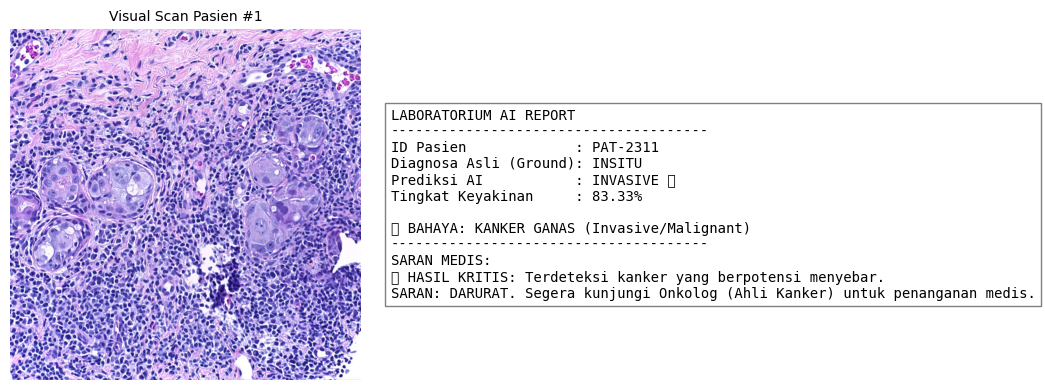

----------------------------------------------------------------------------------------------------


/tmp/ipython-input-189841496.py:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


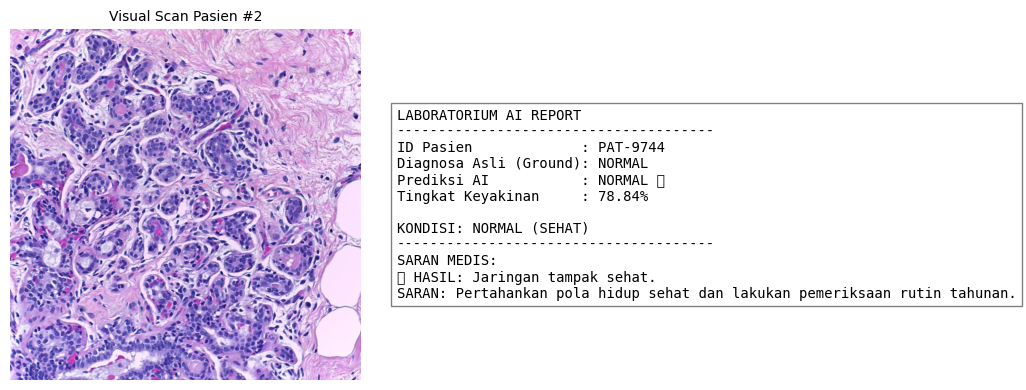

----------------------------------------------------------------------------------------------------


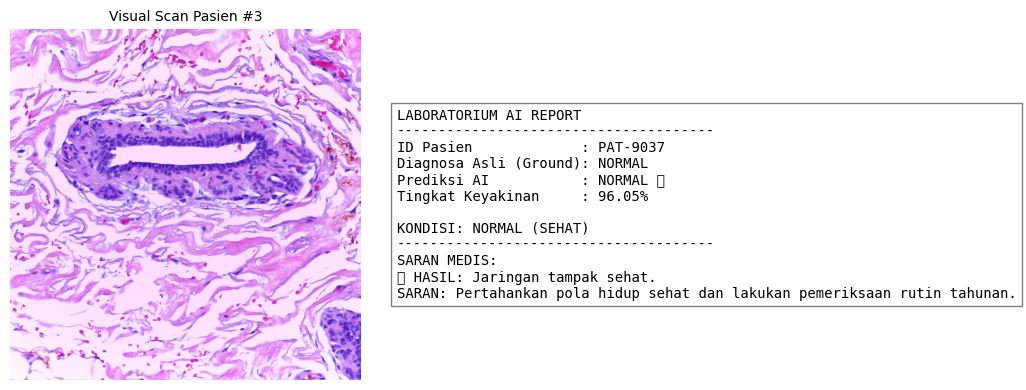

----------------------------------------------------------------------------------------------------


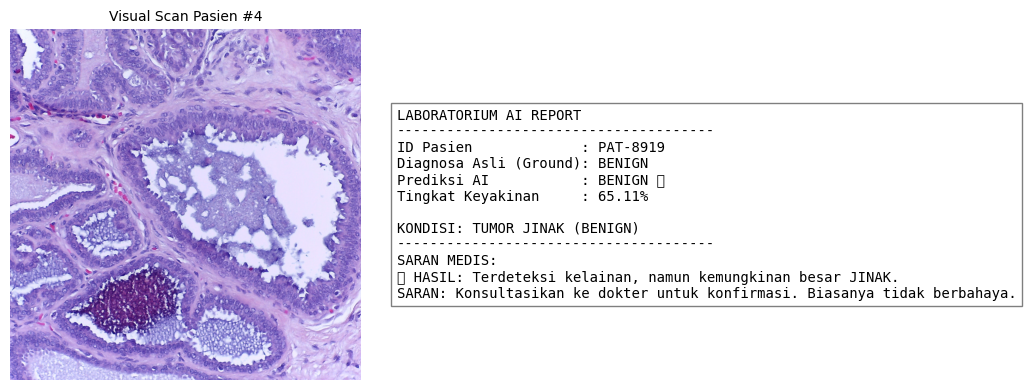

----------------------------------------------------------------------------------------------------


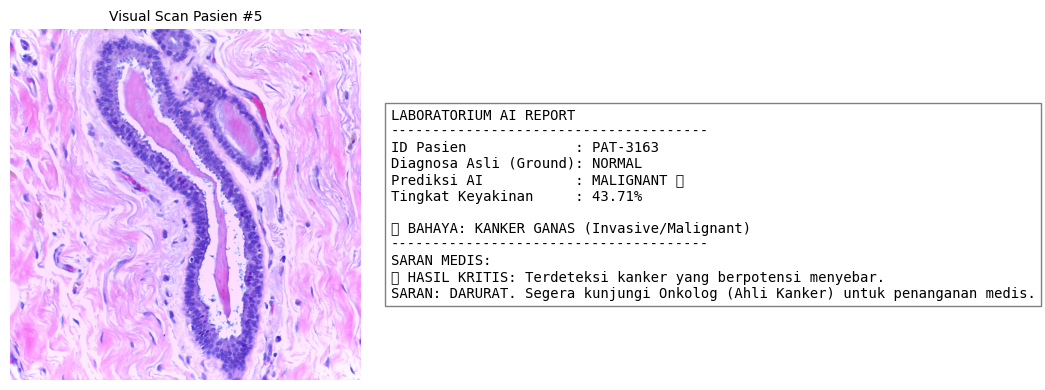

----------------------------------------------------------------------------------------------------


In [ ]:
# ==============================================================================
# SISTEM PREDIKSI & SARAN MEDIS AI (KANKER PAYUDARA) - VERSI DISESUAIKAN
# ==============================================================================

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

def get_medical_advice(pred_name):
    """
    Memberikan saran medis berdasarkan NAMA kelas hasil prediksi.
    Disesuaikan agar fleksibel dengan urutan index di class_map.
    """
    p_name = pred_name.lower()

    # KONDISI: NORMAL / SEHAT (Jika ada di dataset)
    if 'normal' in p_name:
        status = "KONDISI: NORMAL (SEHAT)"
        color = "green"
        advice = (
            "✅ HASIL: Jaringan tampak sehat.\n"
            "SARAN: Pertahankan pola hidup sehat dan lakukan pemeriksaan rutin tahunan."
        )

    # KONDISI: BENIGN (TUMOR JINAK)
    elif 'benign' in p_name:
        status = "KONDISI: TUMOR JINAK (BENIGN)"
        color = "green"
        advice = (
            "✅ HASIL: Terdeteksi kelainan, namun kemungkinan besar JINAK.\n"
            "SARAN: Konsultasikan ke dokter untuk konfirmasi. Biasanya tidak berbahaya."
        )

    # KONDISI: INSITU (KANKER TAHAP AWAL)
    elif 'insitu' in p_name:
        status = "⚠️ PERINGATAN: KANKER TAHAP AWAL (InSitu)"
        color = "darkorange"
        advice = (
            "⚠️ HASIL: Terdeteksi sel kanker yang belum menyebar (Early Stage).\n"
            "SARAN: SEGERA TEMUI DOKTER. Peluang kesembuhan sangat tinggi jika ditangani sekarang."
        )

    # KONDISI: INVASIVE / MALIGNANT (KANKER GANAS)
    elif 'invasive' in p_name or 'malignant' in p_name:
        status = "🚨 BAHAYA: KANKER GANAS (Invasive/Malignant)"
        color = "red"
        advice = (
            "🚨 HASIL KRITIS: Terdeteksi kanker yang berpotensi menyebar.\n"
            "SARAN: DARURAT. Segera kunjungi Onkolog (Ahli Kanker) untuk penanganan medis."
        )

    else:
        status = f"KONDISI: {pred_name.upper()}"
        color = "blue"
        advice = "SARAN: Konsultasikan hasil ini dengan tenaga medis profesional."

    return status, color, advice

def visualize_medical_prediction(model_path, dataframe, class_mapping, num_samples=5):
    print(f"\n{'='*60}")
    print(f"   SIMULASI DIAGNOSA AI & SARAN DOKTER (DATASET A)   ")
    print(f"{'='*60}")

    # 1. Setup Model
    num_classes = len(class_mapping)
    model = ConvNeXtV2_Custom(num_classes=num_classes, pretrained=False).to(DEVICE)

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
        model.eval()
    else:
        print(f"Model {model_path} tidak ditemukan!")
        return

    # Invert mapping: {0: 'benign', 1: 'malignant'}
    inv_class_map = {v: k for k, v in class_mapping.items()}

    # Ambil sampel acak dari dataframe
    if len(dataframe) < num_samples: num_samples = len(dataframe)
    sample_df = dataframe.sample(n=num_samples).reset_index(drop=True)

    # 2. Loop Prediksi
    for i, row in sample_df.iterrows():
        img_path = row['filepath'] # Sesuai dengan CombinedDataManager
        true_label_str = row['label']

        try:
            # Preprocess Image
            original_img = Image.open(img_path).convert('RGB')
            # Menggunakan transforms_val dari pipeline utama Anda
            input_tensor = transforms_val(original_img).unsqueeze(0).to(DEVICE)

            # AI Inference
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                confidence, pred_idx = torch.max(probs, 1)

            pred_name = inv_class_map[pred_idx.item()]
            conf_score = confidence.item() * 100

            # Dapatkan Saran Medis berdasarkan Nama Prediksi
            status_text, status_color, advice_text = get_medical_advice(pred_name)

            # --- VISUALISASI ---
            plt.figure(figsize=(12, 4))

            # Plot Gambar (Kiri)
            plt.subplot(1, 2, 1)
            plt.imshow(original_img)
            plt.axis('off')
            plt.title(f"Visual Scan Pasien #{i+1}", fontsize=10)

            # Plot Teks Saran (Kanan)
            plt.subplot(1, 2, 2)
            plt.axis('off')

            # Cek kecocokan diagnosa (Hanya untuk keperluan riset/evaluasi)
            match_symbol = "✅" if pred_name.lower() == true_label_str.lower() else "❌"

            text_display = (
                f"LABORATORIUM AI REPORT\n"
                f"--------------------------------------\n"
                f"ID Pasien             : PAT-{random.randint(1000, 9999)}\n"
                f"Diagnosa Asli (Ground): {true_label_str.upper()}\n"
                f"Prediksi AI           : {pred_name.upper()} {match_symbol}\n"
                f"Tingkat Keyakinan     : {conf_score:.2f}%\n\n"
                f"{status_text}\n"
                f"--------------------------------------\n"
                f"SARAN MEDIS:\n{advice_text}"
            )

            plt.text(0, 0.5, text_display, fontsize=10, family='monospace',
                     va='center', bbox=dict(facecolor='white', alpha=0.5))

            plt.tight_layout()
            plt.show()
            print("-" * 100)

        except Exception as e:
            print(f"Error pada gambar {img_path}: {e}")

# ==============================================================================
# JALANKAN PROGRAM PREDIKSI
# ==============================================================================

# Gunakan file pth dari salah satu run (misal Run 1)
BEST_RUN_PATH = "best_combined_model_run_1.pth"

if 'test_df' in locals() and 'class_map' in locals():
    # Pastikan file model ada sebelum eksekusi
    visualize_medical_prediction(
        model_path=BEST_RUN_PATH,
        dataframe=test_df,
        class_mapping=class_map,
        num_samples=5
    )
else:
    print("Data test atau class mapping tidak ditemukan. Selesaikan training dahulu.")